In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import calendar

# Timing of event

In [2]:
idate = '2025-10-02'
fdate = '2025-10-05'
dom='HMA+'

# load tp data

In [3]:
tcwv = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/era5/daily/tcwv_daily_era5_2025-10_MA_025x025.nc')

tcwv = tcwv.rename({'valid_time': 'time'})

tcwv = tcwv.sel(time=slice(idate,fdate))
tcwv = field_dom(tcwv,dom)

In [4]:
uivt = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/era5/daily/per_year/uivt_daily_era5_2025_NH_025x025.nc')

uivt = uivt.rename({'valid_time': 'time'})

uivt = uivt.sel(time=slice(idate,fdate))
uivt = field_dom(uivt,dom)

In [5]:
vivt = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/era5/daily/per_year/vivt_daily_era5_2025_NH_025x025.nc')

vivt = vivt.rename({'valid_time': 'time'})

vivt = vivt.sel(time=slice(idate,fdate))
vivt = field_dom(vivt,dom)

# elev data

In [6]:
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/gmted_on_era5_grid.nc')['elevation']
elev = field_dom(elev,dom)

In [7]:
latS,latN,lonW,lonE = coord_domain(dom)

# Spatial Precipitation over event

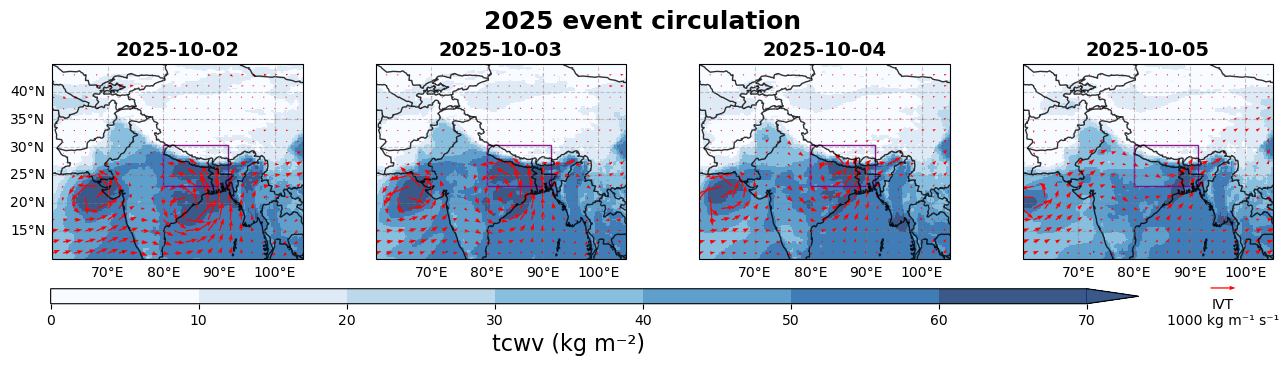

In [8]:
#==================== Color grading ============================

step = 10
vmax = 70
levels = np.arange(0, vmax + step, step)

base_cmap = plt.get_cmap("Blues", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))
#colors[0] = [1, 1, 1, 1]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))

#===================== Plot each day ==================

fig, axes = plt.subplots(
    1, 4,
    figsize=(16, 3),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

for i, ax in enumerate(axes):
    
    data_day = tcwv.tcwv.isel(time=i)
    date = str(tcwv.time.values[i])[:10]

    im = ax.pcolormesh(
        tcwv.longitude,
        tcwv.latitude,
        data_day,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        shading="auto",
        alpha=0.8
    )

    ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

    #tcwv Vectors
    step = 8
    u_plot = uivt['viwve'].isel(time=i)[::step, ::step]
    v_plot = vivt['viwvn'].isel(time=i)[::step, ::step]
    q = ax.quiver(u_plot['longitude'],u_plot['latitude'],u_plot,v_plot,transform=ccrs.PlateCarree(),scale=10000,width=0.005,headwidth=3.5
                 ,rasterized=True, color='red')
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1, alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle="-", alpha=0.8)

    ax.set_title(date, fontsize=14, weight="bold")

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.8,
        color="gray",
        alpha=0.4,
        linestyle="--"
    )

    if i==0:
        gl.left_labels = True
        gl.bottom_labels = True
        gl.top_labels = False
        gl.right_labels = False
    elif i in [1,2,3]:
        gl.left_labels = False
        gl.bottom_labels = True
        gl.top_labels = False
        gl.right_labels = False

    #CH zone
    latS2, latN2, lonW2, lonE2 = coord_domain('CH')
    rect = mpatches.Rectangle((lonW2, latS2), lonE2 - lonW2, latN2 - latS2,linewidth=1, edgecolor='purple', facecolor='none',
                              alpha=0.9, transform=ccrs.PlateCarree())
    ax.add_patch(rect)

#==================== Colorbar ============================

cbar_ax = fig.add_axes([0.13, 0, 0.68, 0.05])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tcwv (kg m⁻²)", fontsize=16)
ax.quiverkey(q,0.80, -0.15,    1000,"IVT\n1000 kg m⁻¹ s⁻¹",labelpos='S',coordinates='axes')
fig.subplots_adjust(top=0.80, bottom=0.15)

#==================== Final ============================

plt.suptitle("2025 event circulation", fontsize=18, weight="bold")
plt.show()